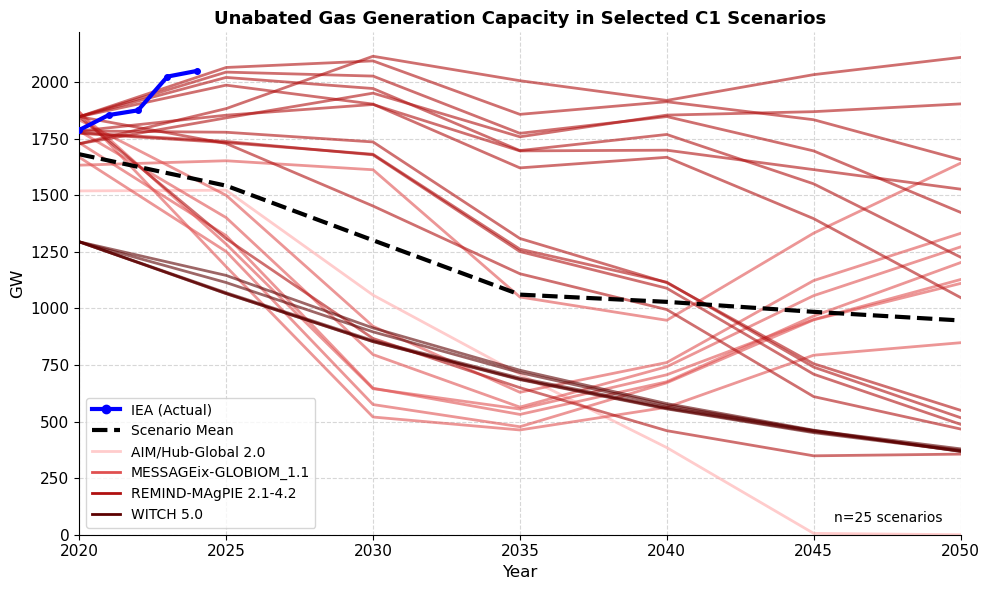

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns in the CSV
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFAAAA',
    'MESSAGEix-GLOBIOM_1.1':     '#E05050',
    'REMIND-MAgPIE 2.1-4.2':     '#B01010',
    'WITCH 5.0':                 '#5C0000',
    'IEA':                       '#0000FF'
}

# --- Data Loading ---
df = pd.read_csv('gas_wo_CCS_ACTUAL.csv')

# Separate IEA from AR6 scenarios
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
# .dropna() connects 2020 to 2025 directly if interim years are missing
for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(overall_mean.index.astype(int), overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]
for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Unabated Gas Generation Capacity in Selected C1 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(handles=legend_elements, loc='lower left', fontsize=10)
# Change the n= annotation to consistent position
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('gas_unabated_capacity_fixed.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

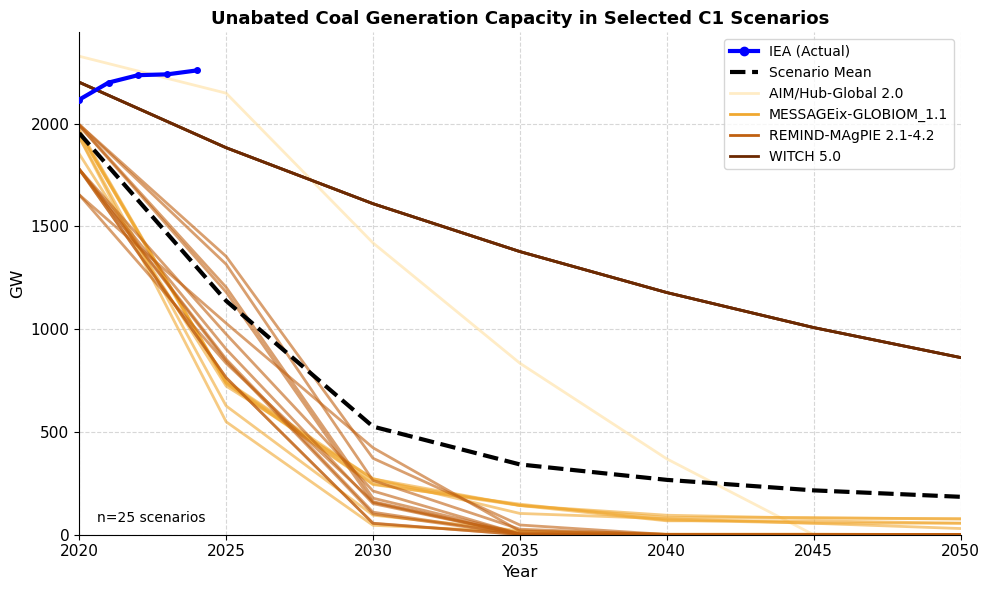

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the new actuals)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFE0A0',
    'MESSAGEix-GLOBIOM_1.1':     '#F0A830',
    'REMIND-MAgPIE 2.1-4.2':     '#C06010',
    'WITCH 5.0':                 '#6B2800',
    'IEA':                       '#0000FF' # Added Blue for IEA Actuals
}

# --- Data Loading ---
# Updated to use the 'ACTUAL' version of the CSV
df = pd.read_csv('coal_wo_CCS_ACTUAL.csv')

# Separate IEA actuals from AR6 scenarios for statistics
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    p25 = scenarios_df[ticks_years].quantile(0.25)
    p75 = scenarios_df[ticks_years].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # .dropna() ensures the line connects 2020 directly to 2025 where data is missing
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
# Only use the major 5-year intervals for the mean line
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Unabated Coal Generation Capacity in Selected C1 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years as requested
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Positioned legend upper right for coal (as it generally trends downward)
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
# Change the n= annotation to consistent position  
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.02, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='left', va='bottom')

plt.tight_layout()
plt.savefig('coal_unabated_capacity_fixed.svg', format='svg', bbox_inches='tight', transparent=True)

plt.show()

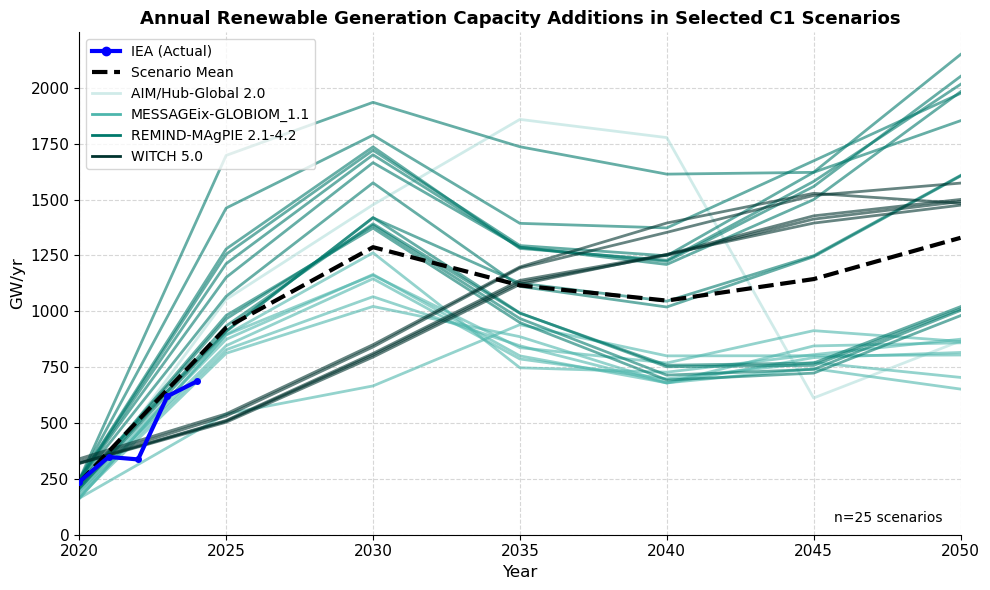

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the interim IEA years)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Ticks set to every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#B2DFDB',
    'MESSAGEix-GLOBIOM_1.1':     '#4DB6AC',
    'REMIND-MAgPIE 2.1-4.2':     '#00796B',
    'WITCH 5.0':                 '#00332E',
    'IEA':                       '#0000FF' # Blue for the Actuals
}

# --- Data Loading ---
# Note: Ensure your CSV is named RE_additions_ACTUAL.csv or update this line
df = pd.read_csv('RE_additions_ACTUAL.csv')

# Separate IEA from the scenarios
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    # Use only major years for shading
    p25 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.25)
    p75 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # dropna() allows the line to jump from 2020 to 2025 for scenarios
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Annual Renewable Generation Capacity Additions in Selected C1 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('RE_additions.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

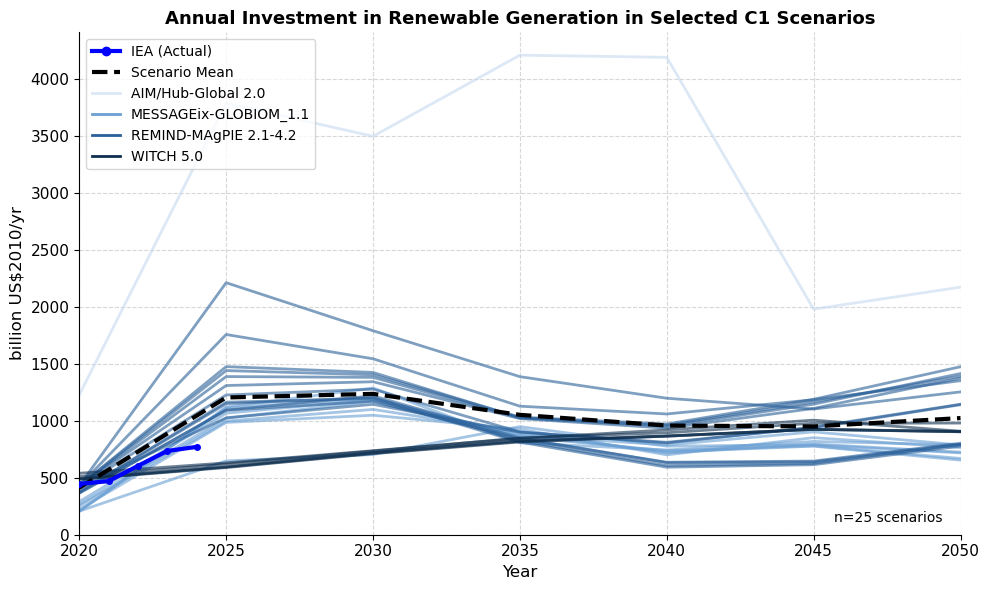

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the new actuals)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#C6D9F0',
    'MESSAGEix-GLOBIOM_1.1':     '#6A9FD4',
    'REMIND-MAgPIE 2.1-4.2':     '#2A6099',
    'WITCH 5.0':                 '#0D2E4E',
    'IEA':                       '#0000FF' # Added Blue for IEA Actuals
}

# --- Data Loading ---
# Updated to use the 'ACTUAL' version of the CSV
df = pd.read_csv('RE_Investment_ACTUAL.csv')

# Separate IEA actuals from AR6 scenarios for statistics
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    p25 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.25)
    p75 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # .dropna() ensures the line connects 2020 directly to 2025 where data is missing
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
# Only use the major 5-year intervals for the mean line
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Annual Investment in Renewable Generation in Selected C1 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('RE_investment_fixed.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

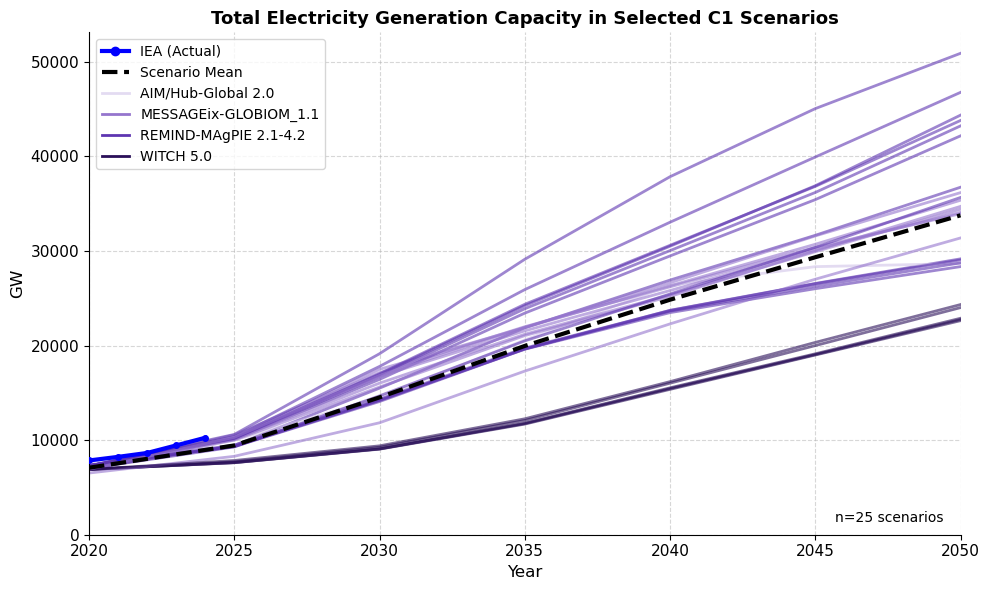

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the new actuals)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#D1C4E9',
    'MESSAGEix-GLOBIOM_1.1':     '#9575CD',
    'REMIND-MAgPIE 2.1-4.2':     '#5E35B1',
    'WITCH 5.0':                 '#2A1059',
    'IEA':                       '#0000FF'
}

# --- Data Loading ---
df = pd.read_csv('total_capacity_ACTUAL.csv')

# Separate IEA actuals from AR6 scenarios for statistics
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    p25 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.25)
    p75 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # .dropna() ensures the line connects 2020 directly to 2025 where data is missing
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
# Only use the major 5-year intervals for the mean line
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Total Electricity Generation Capacity in Selected C1 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Positioned legend upper left for growth curves
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('total_capacity_with_IEA.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

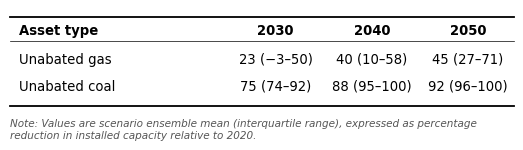

In [58]:
import pandas as pd
import matplotlib.pyplot as plt


# ── 1. Data Processing ──────────────────────────────────────────────
def get_asset_reductions(file_name, asset_label):
    df = pd.read_csv(file_name)
    scenarios = df[df['Model'] != 'IEA']

    results = {}
    for yr in ['2030', '2040', '2050']:
        red = (1 - (scenarios[yr] / scenarios['2020'])) * 100
        mean = red.mean()
        p25 = red.quantile(0.25)
        p75 = red.quantile(0.75)
        lo, hi = sorted([p25, p75])

        def fmt_num(v):
            return f"\u2212{abs(v):.0f}" if v < 0 else f"{v:.0f}"

        results[yr] = f"{fmt_num(mean)} ({fmt_num(lo)}\u2013{fmt_num(hi)})"
    return asset_label, results

gas_label, gas = get_asset_reductions('gas_wo_CCS_ACTUAL.csv', 'Unabated gas')
coal_label, coal = get_asset_reductions('coal_wo_CCS_ACTUAL.csv', 'Unabated coal')

# ── 2. Build table ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

fig, ax = plt.subplots(figsize=(6.5, 1.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.6)
ax.axis('off')

x0 = 0.2
x_data = [5.8, 7.9, 10.0]

heavy = dict(color='black', linewidth=1.3, clip_on=False)
thin  = dict(color='black', linewidth=0.5, clip_on=False)

ax.plot([0, 11], [3.35, 3.35], **heavy)   # toprule
ax.plot([0, 11], [2.6, 2.6],   **thin)    # midrule
ax.plot([0, 11], [0.6, 0.6],   **heavy)   # bottomrule

# ── Header ──
hy = 2.95
ax.text(x0, hy, 'Asset type', fontsize=9.5, fontweight='bold',
        ha='left', va='center')
for x, yr in zip(x_data, ['2030', '2040', '2050']):
    ax.text(x, hy, yr, fontsize=9.5, fontweight='bold',
            ha='center', va='center')

# ── Data ──
rows = [(gas_label, gas), (coal_label, coal)]
row_ys = [2.05, 1.2]

for (label, vals), y in zip(rows, row_ys):
    ax.text(x0, y, label, fontsize=9.5, ha='left', va='center')
    for x, yr in zip(x_data, ['2030', '2040', '2050']):
        ax.text(x, y, vals[yr], fontsize=9.5, ha='center', va='center')

# ── Footnote ──
note = ('Note: Values are scenario ensemble mean (interquartile range), '
        'expressed as percentage \nreduction in installed capacity relative to 2020.')
ax.text(0, 0.2, note, fontsize=7.5, fontstyle='italic', ha='left', va='top',
        color='#555555')

plt.savefig('journal_table_final.svg', bbox_inches='tight',
            facecolor='white')
plt.show()

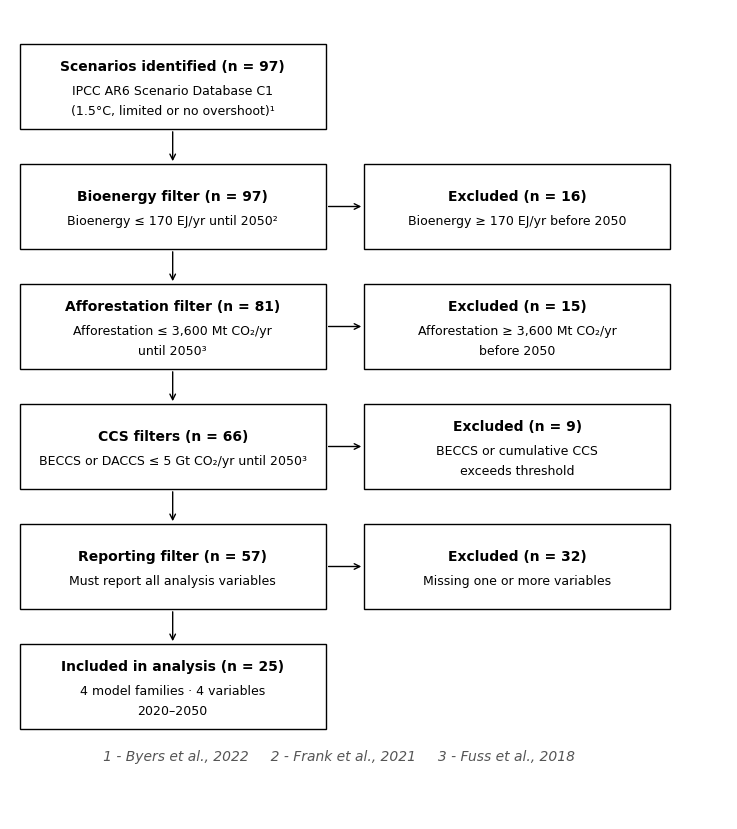

In [257]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7.5, 8.4))
ax.set_xlim(0, 7.5)
ax.set_ylim(0.6, 8.7)
ax.axis('off')

# --- Style ---
box_fc = 'white'
box_ec = 'black'
box_lw = 1.0
arrow_color = 'black'
arrow_lw = 1.0
font_family = 'sans-serif'
font_size_bold = 10
font_size_body = 9

# --- Layout ---
box_w = 3.2
box_h = 0.85
gap_x = 0.4
main_x = 0.1
excl_x = main_x + box_w + gap_x
arrow_gap = 0.35


def draw_box(x, y_pos, lines, bold_line=None):
    rect = mpatches.FancyBboxPatch(
        (x, y_pos), box_w, box_h,
        boxstyle="square,pad=0",
        facecolor=box_fc, edgecolor=box_ec, linewidth=box_lw)
    ax.add_patch(rect)
    body_spacing = 0.20
    bold_gap = 0.24
    block_h = 0
    if bold_line:
        block_h += bold_gap
    if len(lines) > 1:
        block_h += (len(lines) - 1) * body_spacing
    centre_y = y_pos + box_h / 2 - 0.02
    top_y = centre_y + block_h / 2
    cur_y = top_y
    if bold_line:
        ax.text(x + box_w / 2, cur_y, bold_line,
                ha='center', va='center', fontsize=font_size_bold,
                fontweight='bold', family=font_family)
        cur_y -= bold_gap
    for line in lines:
        ax.text(x + box_w / 2, cur_y, line,
                ha='center', va='center', fontsize=font_size_body,
                family=font_family)
        cur_y -= body_spacing


def arrow_down(y_from, y_to):
    ax.annotate('',
                xy=(main_x + box_w / 2, y_to + box_h),
                xytext=(main_x + box_w / 2, y_from),
                arrowprops=dict(arrowstyle='->', color=arrow_color, lw=arrow_lw))


def arrow_right(y_box):
    mid_y = y_box + box_h / 2
    ax.annotate('',
                xy=(excl_x, mid_y),
                xytext=(main_x + box_w, mid_y),
                arrowprops=dict(arrowstyle='->', color=arrow_color, lw=arrow_lw))


y = 7.5

# === IDENTIFICATION ===
id_y = y
draw_box(main_x, id_y,
         bold_line='Scenarios identified (n = 97)',
         lines=['IPCC AR6 Scenario Database C1',
                '(1.5\u00b0C, limited or no overshoot)\u00b9'])
y = id_y - box_h - arrow_gap

# === FILTER 1: Bioenergy ===
f1_y = y
draw_box(main_x, f1_y,
         bold_line='Bioenergy filter (n = 97)',
         lines=['Bioenergy \u2264 170 EJ/yr until 2050\u00b2'])
arrow_down(id_y, f1_y)
arrow_right(f1_y)
draw_box(excl_x, f1_y,
         bold_line='Excluded (n = 16)',
         lines=['Bioenergy \u2265 170 EJ/yr before 2050'])
y = f1_y - box_h - arrow_gap

# === FILTER 2: Afforestation ===
f2_y = y
draw_box(main_x, f2_y,
         bold_line='Afforestation filter (n = 81)',
         lines=['Afforestation \u2264 3,600 Mt CO\u2082/yr',
               'until 2050\u00b3'])
arrow_down(f1_y, f2_y)
arrow_right(f2_y)
draw_box(excl_x, f2_y,
         bold_line='Excluded (n = 15)',
         lines=['Afforestation \u2265 3,600 Mt CO\u2082/yr',
               'before 2050'])
y = f2_y - box_h - arrow_gap

# === FILTER 3: CCS ===
f3_y = y
draw_box(main_x, f3_y,
         bold_line='CCS filters (n = 66)',
         lines=['BECCS or DACCS \u2264 5 Gt CO\u2082/yr until 2050\u00b3'])
arrow_down(f2_y, f3_y)
arrow_right(f3_y)
draw_box(excl_x, f3_y,
         bold_line='Excluded (n = 9)',
         lines=['BECCS or cumulative CCS',
                'exceeds threshold'])
y = f3_y - box_h - arrow_gap

# === FILTER 4: Reporting ===
f4_y = y
draw_box(main_x, f4_y,
         bold_line='Reporting filter (n = 57)',
         lines=['Must report all analysis variables'])

arrow_down(f3_y, f4_y)
arrow_right(f4_y)
draw_box(excl_x, f4_y,
         bold_line='Excluded (n = 32)',
         lines=['Missing one or more variables'])

y = f4_y - box_h - arrow_gap

# === INCLUDED ===
inc_y = y
draw_box(main_x, inc_y,
         bold_line='Included in analysis (n = 25)',
         lines=['4 model families \u00b7 4 variables',
                '2020\u20132050'])
arrow_down(f4_y, inc_y)

# === NOTE ===
note = (
    '                   1 - Byers et al., 2022     '
    '2 - Frank et al., 2021     '
    '3 - Fuss et al., 2018    '
)
ax.text(main_x, inc_y - 0.2, note,
        fontsize=10.0, fontstyle='italic', ha='left', va='top',
        color='#555555', family=font_family)

plt.tight_layout()
plt.savefig('prisma_scenario_filtering.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

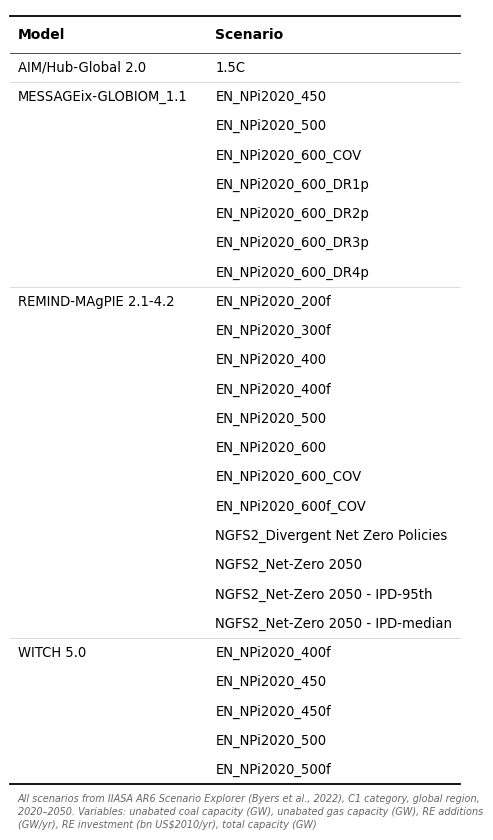

In [269]:
import matplotlib.pyplot as plt

# ── 1. Scenario data ────────────────────────────────────────────────
scenarios = [
    ('AIM/Hub-Global 2.0', '1.5C'),
    ('MESSAGEix-GLOBIOM_1.1', 'EN_NPi2020_450'),
    ('MESSAGEix-GLOBIOM_1.1', 'EN_NPi2020_500'),
    ('MESSAGEix-GLOBIOM_1.1', 'EN_NPi2020_600_COV'),
    ('MESSAGEix-GLOBIOM_1.1', 'EN_NPi2020_600_DR1p'),
    ('MESSAGEix-GLOBIOM_1.1', 'EN_NPi2020_600_DR2p'),
    ('MESSAGEix-GLOBIOM_1.1', 'EN_NPi2020_600_DR3p'),
    ('MESSAGEix-GLOBIOM_1.1', 'EN_NPi2020_600_DR4p'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_200f'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_300f'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_400'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_400f'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_500'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_600'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_600_COV'),
    ('REMIND-MAgPIE 2.1-4.2', 'EN_NPi2020_600f_COV'),
    ('REMIND-MAgPIE 2.1-4.2', 'NGFS2_Divergent Net Zero Policies'),
    ('REMIND-MAgPIE 2.1-4.2', 'NGFS2_Net-Zero 2050'),
    ('REMIND-MAgPIE 2.1-4.2', 'NGFS2_Net-Zero 2050 - IPD-95th'),
    ('REMIND-MAgPIE 2.1-4.2', 'NGFS2_Net-Zero 2050 - IPD-median'),
    ('WITCH 5.0', 'EN_NPi2020_400f'),
    ('WITCH 5.0', 'EN_NPi2020_450'),
    ('WITCH 5.0', 'EN_NPi2020_450f'),
    ('WITCH 5.0', 'EN_NPi2020_500'),
    ('WITCH 5.0', 'EN_NPi2020_500f'),
]

# ── 2. Layout ───────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

n_rows = len(scenarios)
row_h = 0.38
header_h = 0.48
footer_h = 0.55
fig_h = header_h + n_rows * row_h + footer_h
fig_w = 5.8

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, fig_w)
ax.set_ylim(0, fig_h)
ax.axis('off')

heavy = dict(color='black', linewidth=1.3, clip_on=False)
thin  = dict(color='black', linewidth=0.5, clip_on=False)

x_model = 0.1
x_scenario = 2.65

# ── 3. Header ───────────────────────────────────────────────────────
top_y = fig_h - 0.08
mid_y = top_y - header_h
ax.plot([0, fig_w], [top_y, top_y], **heavy)
ax.plot([0, fig_w], [mid_y, mid_y], **thin)

hy = top_y - header_h / 2
ax.text(x_model, hy, 'Model', fontsize=10, fontweight='bold',
        ha='left', va='center')
ax.text(x_scenario, hy, 'Scenario', fontsize=10, fontweight='bold',
        ha='left', va='center')

# ── 4. Data rows ────────────────────────────────────────────────────
prev_model = None
for i, (model, scenario) in enumerate(scenarios):
    y = mid_y - (i + 0.5) * row_h

    if prev_model is not None and model != prev_model:
        sep_y = mid_y - i * row_h
        ax.plot([0, fig_w], [sep_y, sep_y],
                color='#CCCCCC', linewidth=0.5, clip_on=False)

    if model != prev_model:
        ax.text(x_model, y, model, fontsize=9.5, ha='left', va='center')

    ax.text(x_scenario, y, scenario, fontsize=9.5, ha='left', va='center')

    prev_model = model

# ── 5. Bottom rule ──────────────────────────────────────────────────
bot_y = mid_y - n_rows * row_h
ax.plot([0, fig_w], [bot_y, bot_y], **heavy)

# ── 6. Footnote ─────────────────────────────────────────────────────
note = (
    'All scenarios from IIASA AR6 Scenario Explorer (Byers et al., 2022), '
    'C1 category, global region,\n'
    '2020\u20132050. Variables: unabated coal capacity (GW), unabated gas capacity (GW), '
    'RE additions\n(GW/yr), RE investment (bn US$2010/yr), total capacity (GW)'
)
ax.text(0.1, bot_y - 0.12, note, fontsize=7, fontstyle='italic',
        ha='left', va='top', color='#666666', linespacing=1.4)

plt.savefig('scenario_summary_table.svg', bbox_inches='tight', facecolor='white')
plt.show()

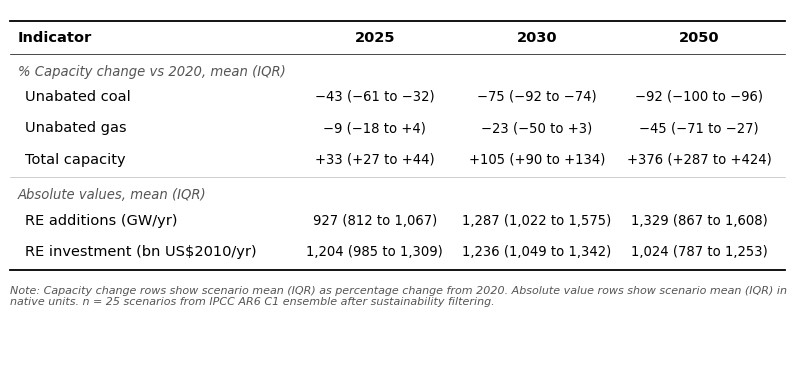

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

def get_pct_change(file_name, asset_label):
    df = pd.read_csv(file_name)
    scenarios = df[df['Model'] != 'IEA']
    results = {}
    for yr in ['2025', '2030', '2050']:
        if yr not in scenarios.columns:
            results[yr] = '—'
            continue
        chg = ((scenarios[yr] / scenarios['2020']) - 1) * 100
        mean = chg.mean()
        p25 = chg.quantile(0.25)
        p75 = chg.quantile(0.75)
        lo, hi = sorted([p25, p75])
        def fmt(v):
            sign = '+' if v > 0 else ('\u2212' if v < 0 else '')
            return f"{sign}{abs(v):.0f}"
        results[yr] = f"{fmt(mean)} ({fmt(lo)} to {fmt(hi)})"
    return asset_label, results

def get_absolute_values(file_name, asset_label):
    df = pd.read_csv(file_name)
    scenarios = df[df['Model'] != 'IEA']
    results = {}
    for yr in ['2025', '2030', '2050']:
        if yr not in scenarios.columns:
            results[yr] = '—'
            continue
        vals = scenarios[yr].dropna()
        mean = vals.mean()
        p25 = vals.quantile(0.25)
        p75 = vals.quantile(0.75)
        results[yr] = f"{mean:,.0f} ({p25:,.0f} to {p75:,.0f})"
    return asset_label, results

coal_label,  coal  = get_pct_change('coal_wo_CCS_ACTUAL.csv', 'Unabated coal')
gas_label,   gas   = get_pct_change('gas_wo_CCS_ACTUAL.csv',  'Unabated gas')
total_label, total = get_pct_change('total_capacity_ACTUAL.csv', 'Total capacity')
re_add_label, re_add = get_absolute_values('RE_additions_ACTUAL.csv', 'RE additions')
re_inv_label, re_inv = get_absolute_values('RE_Investment_ACTUAL.csv', 'RE investment')

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"]})

fig, ax = plt.subplots(figsize=(10.0, 4.8))
ax.set_xlim(0, 15.3)
ax.set_ylim(0, 8.2)
ax.axis('off')

x0 = 0.15
# Spread columns: start earlier, end later, staying inside the w=15 bars
x_data = [7.2, 10.4, 13.6]
years  = ['2025', '2030', '2050']

heavy = dict(color='black', linewidth=1.3, clip_on=False)
thin  = dict(color='black', linewidth=0.5, clip_on=False)
light = dict(color='#BBBBBB', linewidth=0.5, clip_on=False)
w = 15.3

# Header
ax.plot([0, w], [7.95, 7.95], **heavy)
hy = 7.58
ax.text(x0, hy, 'Indicator', fontsize=10.5, fontweight='bold', ha='left', va='center')
for x, yr in zip(x_data, years):
    ax.text(x, hy, yr, fontsize=10.5, fontweight='bold', ha='center', va='center')
ax.plot([0, w], [7.20, 7.20], **thin)

# Block 1
ax.text(x0, 6.82,
        '% Capacity change vs 2020, mean (IQR)',
        fontsize=9.5, fontstyle='italic', ha='left', va='center', color='#555555')

rows_b1 = [(coal_label, coal), (gas_label, gas), (total_label, total)]
ys_b1   = [6.28, 5.58, 4.88]

for (label, vals), y in zip(rows_b1, ys_b1):
    ax.text(x0 + 0.15, y, label, fontsize=10.5, ha='left', va='center')
    for x, yr in zip(x_data, years):
        ax.text(x, y, vals.get(yr, '—'), fontsize=9.5, ha='center', va='center')

ax.plot([0, w], [4.48, 4.48], **light)

# Block 2
ax.text(x0, 4.10,
        'Absolute values, mean (IQR)',
        fontsize=9.5, fontstyle='italic', ha='left', va='center', color='#555555')

rows_b2 = [('RE additions (GW/yr)', re_add), ('RE investment (bn US$2010/yr)', re_inv)]
ys_b2   = [3.52, 2.82]

for (label, vals), y in zip(rows_b2, ys_b2):
    ax.text(x0 + 0.15, y, label, fontsize=10.5, ha='left', va='center')
    for x, yr in zip(x_data, years):
        ax.text(x, y, vals.get(yr, '—'), fontsize=9.5, ha='center', va='center')

ax.plot([0, w], [2.42, 2.42], **heavy)

# Footnote
note = (
    'Note: Capacity change rows show scenario mean (IQR) as percentage change from 2020. '
    'Absolute value rows show scenario mean (IQR) in\nnative units.'
    ' n = 25 scenarios from IPCC AR6 C1 ensemble after sustainability filtering.'
)
ax.text(0, 2.08, note, fontsize=8.0, fontstyle='italic', ha='left', va='top', color='#555555')

plt.savefig('benchmark_table.svg', bbox_inches='tight', facecolor='white')
plt.savefig('benchmark_table.pdf', bbox_inches='tight', facecolor='white')

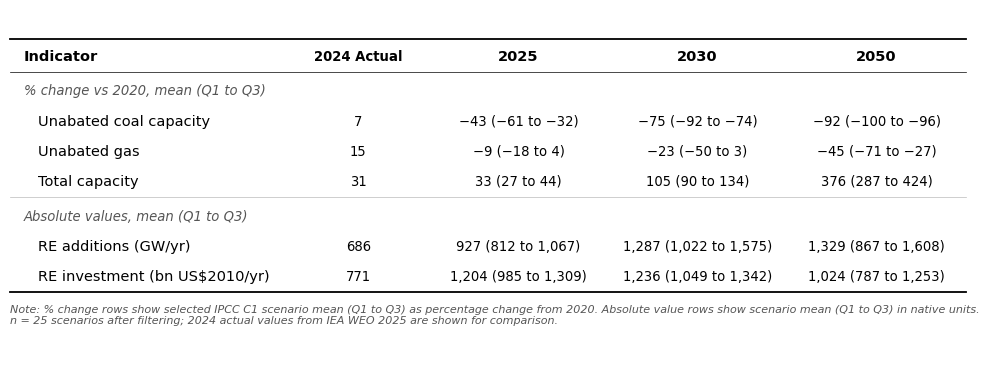

In [153]:
import pandas as pd
import matplotlib.pyplot as plt


def get_pct_change(file_name, asset_label):
    df = pd.read_csv(file_name)
    scenarios = df[df['Model'] != 'IEA']
    iea_row = df[df['Model'] == 'IEA']

    def fmt(v):
        return f"−{abs(v):.0f}" if v < 0 else f"{v:.0f}"

    results = {}
    for yr in ['2025', '2030', '2050']:
        if yr not in scenarios.columns:
            results[yr] = '—'
            continue
        chg = ((scenarios[yr] / scenarios['2020']) - 1) * 100
        mean = chg.mean()
        p25 = chg.quantile(0.25)
        p75 = chg.quantile(0.75)
        lo, hi = sorted([p25, p75])
        results[yr] = f"{fmt(mean)} ({fmt(lo)} to {fmt(hi)})"

    iea_val = '—'
    if not iea_row.empty and '2024' in iea_row.columns and '2020' in iea_row.columns:
        v2024 = pd.to_numeric(iea_row['2024'].values[0], errors='coerce')
        v2020 = pd.to_numeric(iea_row['2020'].values[0], errors='coerce')
        if pd.notna(v2024) and pd.notna(v2020) and v2020 != 0:
            pct = ((v2024 / v2020) - 1) * 100
            iea_val = fmt(pct)

    return asset_label, results, iea_val


def get_absolute_values(file_name, asset_label):
    df = pd.read_csv(file_name)
    scenarios = df[df['Model'] != 'IEA']
    iea_row = df[df['Model'] == 'IEA']

    results = {}
    for yr in ['2025', '2030', '2050']:
        if yr not in scenarios.columns:
            results[yr] = '—'
            continue
        vals = scenarios[yr].dropna()
        mean = vals.mean()
        p25 = vals.quantile(0.25)
        p75 = vals.quantile(0.75)
        results[yr] = f"{mean:,.0f} ({p25:,.0f} to {p75:,.0f})"

    iea_val = '—'
    if not iea_row.empty and '2024' in iea_row.columns:
        v2024 = pd.to_numeric(iea_row['2024'].values[0], errors='coerce')
        if pd.notna(v2024):
            iea_val = f"{v2024:,.0f}"

    return asset_label, results, iea_val


coal_label,  coal,  coal_iea  = get_pct_change('coal_wo_CCS_ACTUAL.csv',    'Unabated coal capacity')
gas_label,   gas,   gas_iea   = get_pct_change('gas_wo_CCS_ACTUAL.csv',     'Unabated gas ')
total_label, total, total_iea = get_pct_change('total_capacity_ACTUAL.csv', 'Total capacity')
re_add_label, re_add, re_add_iea = get_absolute_values('RE_additions_ACTUAL.csv',  'RE additions (GW/yr)')
re_inv_label, re_inv, re_inv_iea = get_absolute_values('RE_Investment_ACTUAL.csv', 'RE investment (bn US$2010/yr)')


# ════════════════════════════════════════════════════════════════════════════
#  SPACING CONTROLS  —  adjust these to tune the layout
# ════════════════════════════════════════════════════════════════════════════

ROW_H         = 0.4  # Vertical pitch between rows. All vertical spacing scales with this.

IEA_GAP_LEFT  = 5     # Distance from x=0 (col 0 anchor) to IEA column centre.
IEA_GAP_RIGHT = 2.3   # Distance from IEA column centre to 2025 column centre.
COL_GAP       = 2.57  # Uniform gap between 2025 → 2030 → 2050.

# ════════════════════════════════════════════════════════════════════════════

x0     = 0.20
x_iea  = IEA_GAP_LEFT
x_2025 = x_iea  + IEA_GAP_RIGHT
x_data = [x_2025 + COL_GAP * i for i in range(3)]
years  = ['2025', '2030', '2050']

w_left  = 0.0
w_right = x_data[-1] + COL_GAP * 0.50

HDR_H   = ROW_H * 1.10
BLK_PAD = ROW_H * 0.60
TOP     = 7.60

hdr_mid  = TOP - HDR_H * 0.50
hdr_bot  = TOP - HDR_H
sub1_y   = hdr_bot  - BLK_PAD
row1_ys  = [sub1_y  - ROW_H * (i + 1) for i in range(3)]
div_y    = row1_ys[-1] - ROW_H * 0.55
sub2_y   = div_y    - BLK_PAD
row2_ys  = [sub2_y  - ROW_H * (i + 1) for i in range(2)]
bot_y    = row2_ys[-1] - ROW_H * 0.55
footnote_y = bot_y - 0.15

fig_h = TOP - footnote_y + 1.10
fig_w = max(12.0, (w_right + 0.6) * 0.88)

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"]})
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.set_xlim(w_left, w_right + 0.3)
ax.set_ylim(footnote_y - 0.80, TOP + 0.40)
ax.axis('off')

heavy = dict(color='black',   linewidth=1.3, clip_on=False)
thin  = dict(color='black',   linewidth=0.5, clip_on=False)
light = dict(color='#BBBBBB', linewidth=0.5, clip_on=False)

# ── Header ───────────────────────────────────────────────────────────────────
ax.plot([w_left, w_right], [TOP,     TOP],     **heavy)
ax.plot([w_left, w_right], [hdr_bot, hdr_bot], **thin)
ax.text(x0,    hdr_mid, 'Indicator',       fontsize=10.5, fontweight='bold', ha='left',   va='center')
ax.text(x_iea, hdr_mid, '2024 Actual', fontsize=9.5,  fontweight='bold', ha='center', va='center')
for x, yr in zip(x_data, years):
    ax.text(x, hdr_mid, yr, fontsize=10.5, fontweight='bold', ha='center', va='center')

# ── Block 1 ──────────────────────────────────────────────────────────────────
ax.text(x0, sub1_y, '% change vs 2020, mean (Q1 to Q3)',
        fontsize=9.5, fontstyle='italic', ha='left', va='center', color='#555555')

for (label, vals, iea_val), y in zip(
        [(coal_label,  coal,  coal_iea),
         (gas_label,   gas,   gas_iea),
         (total_label, total, total_iea)],
        row1_ys):
    ax.text(x0 + 0.20, y, label,   fontsize=10.5, ha='left',   va='center')
    ax.text(x_iea,     y, iea_val, fontsize=9.5,  ha='center', va='center')
    for x, yr in zip(x_data, years):
        ax.text(x, y, vals.get(yr, '—'), fontsize=9.5, ha='center', va='center')

ax.plot([w_left, w_right], [div_y, div_y], **light)

# ── Block 2 ──────────────────────────────────────────────────────────────────
ax.text(x0, sub2_y, 'Absolute values, mean (Q1 to Q3)',
        fontsize=9.5, fontstyle='italic', ha='left', va='center', color='#555555')

for (label, vals, iea_val), y in zip(
        [('RE additions (GW/yr)',          re_add, re_add_iea),
         ('RE investment (bn US$2010/yr)', re_inv, re_inv_iea)],
        row2_ys):
    ax.text(x0 + 0.20, y, label,   fontsize=10.5, ha='left',   va='center')
    ax.text(x_iea,     y, iea_val, fontsize=9.5,  ha='center', va='center')
    for x, yr in zip(x_data, years):
        ax.text(x, y, vals.get(yr, '—'), fontsize=9.5, ha='center', va='center')

ax.plot([w_left, w_right], [bot_y, bot_y], **heavy)

# ── Footnote ─────────────────────────────────────────────────────────────────
note = (
    'Note: % change rows show selected IPCC C1 scenario mean (Q1 to Q3) as percentage change from 2020. '
    'Absolute value rows show scenario mean (Q1 to Q3) in native units.\n'
    'n = 25 scenarios after filtering; '
    '2024 actual values from IEA WEO 2025 are shown for comparison.'
  
)
ax.text(w_left, footnote_y, note,
        fontsize=8.0, fontstyle='italic', ha='left', va='top', color='#555555')

plt.savefig('benchmark_table.svg', bbox_inches='tight', facecolor='white')
plt.savefig('benchmark_table.pdf', bbox_inches='tight', facecolor='white')
plt.show()